Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.


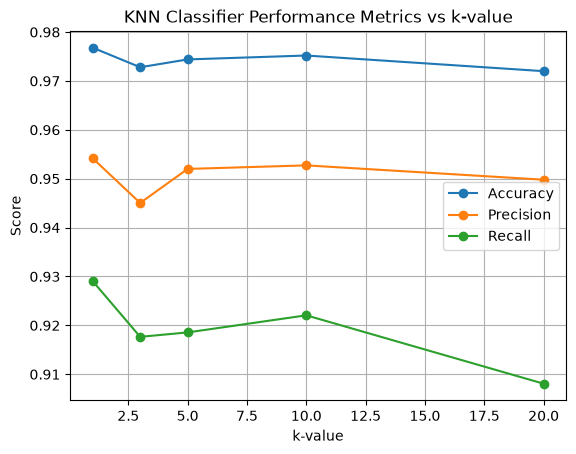

  Algorithm Parameters  Accuracy  Precision    Recall
0       KNN        k=1    0.9768   0.954174  0.929050
1       KNN        k=3    0.9728   0.945039  0.917657
2       KNN        k=5    0.9744   0.952002  0.918560
3       KNN       k=10    0.9752   0.952729  0.922057
4       KNN       k=20    0.9720   0.949797  0.908071


In [ ]:
# Ananth Kashibhatla
# 16 September 2026
# Professor Dawn Ryalt/ML

# Task 1: Data Preprocessing
%pip install matplotlib

# Import the pandas and numpy libraries
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.neighbors import KNeighborsClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score
import matplotlib.pyplot as plt   
# Load the Malware dataset file into dataframe variable intialized
df_malware_dataset = pd.read_csv('C:/Users/kashibhatla.anant/Downloads/Malware dataset.csv')

# Explore the dataset structures
# print(df_malware_dataset.head())
# print(df_malware_dataset.tail())
# print(len(df_malware_dataset))
# print(df_malware_dataset.shape)
# print(df_malware_dataset.dtypes)

# Separate features and target
X = df_malware_dataset.drop(columns=["label"])
y = df_malware_dataset["label"]

# Split Malware dataset into training and testing sets(80% training and 20 % testing)
X_train, X_test, y_train, y_test = train_test_split(
    X,y)
# print(X)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size = 0.2, random_state = 42)
#print(X_test)
#print(y_test)
# Task 2: Model Training and Evaluation

# Try different k-values for KNN classifier
knn_values = [1, 3, 5, 10, 20]

accuracy_scores = []
precision_scores = []
recall_scores = []

for k in knn_values:
    # Create and train KNN classifier
    knn = KNeighborsClassifier(n_neighbors=k)
    # Fit the model and make predictions
    knn.fit(X_train, y_train)
    # Make predictions on the test set
    y_pred = knn.predict(X_test)
    # Calculate accuracy, precision, and recall
    accuracy_scores.append(accuracy_score(y_test, y_pred))
    precision_scores.append(precision_score(y_test, y_pred, average='macro'))
    recall_scores.append(recall_score(y_test, y_pred, average='macro'))

# Task 3: Graph Accuracy vs k-value
# Plot the accuracy, precision, and recall scores against k-values
plt.plot(knn_values, accuracy_scores, marker='o', label='Accuracy')
plt.plot(knn_values, precision_scores, marker='o', label='Precision')
plt.plot(knn_values, recall_scores, marker='o', label='Recall')
# Add labels and title to the plot
plt.title('KNN Classifier Performance Metrics vs k-value')
plt.xlabel('k-value')
plt.ylabel('Score')

# Add a legend to the plot
plt.legend()
plt.grid()

# Show the plot
plt.show()


# Summary table with Algorithm, Paramters, Accuracy, Precision, and Recall
summary_table = pd.DataFrame({
    'Algorithm': ['KNN'] * len(knn_values),
    'Parameters': [f'k={k}' for k in knn_values],
    'Accuracy': accuracy_scores,
    'Precision': precision_scores,
    'Recall': recall_scores
})
print(summary_table)